In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr, spearmanr

sns.set_context('notebook')
sns.set_style('whitegrid')

In [2]:
# Setup paths
prefix = '/home/ines/repositories/'
firing_rates_dir = prefix + 'representation_learning_variability/paper-individuality/data/firing_rates/'
clustering_dir = prefix + 'representation_learning_variability/paper-individuality/clustering/'

print(f"Firing rates directory: {firing_rates_dir}")
print(f"Clustering directory: {clustering_dir}")

Firing rates directory: /home/ines/repositories/representation_learning_variability/paper-individuality/data/firing_rates/
Clustering directory: /home/ines/repositories/representation_learning_variability/paper-individuality/clustering/


## Load Firing Rate Data

In [11]:
def load_all_firing_rates(firing_rates_dir, max_files=None):
    """Load all firing rate files and compute mean per neuron (across trials) before concatenating"""
    pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
    if max_files:
        pkl_files = pkl_files[:max_files]

    all_neuron_dfs = []
    for i, pkl_file in enumerate(pkl_files):
        try:
            with open(os.path.join(firing_rates_dir, pkl_file), 'rb') as f:
                data = pickle.load(f)

            # Extract time columns and identify baseline period
            time_cols = [col for col in data.columns if col.startswith('t_')]
            time_values = np.array([float(col.split('_')[1]) for col in time_cols])
            baseline_mask = (time_values >= -0) & (time_values <= .2)
            baseline_cols = [col for col, mask in zip(time_cols, baseline_mask) if mask]

            # Calculate baseline firing rate per trial
            data['baseline_fr'] = np.nanmean(data[baseline_cols].values, axis=1)

            # Aggregate to per-neuron level (mean across trials)
            neuron_agg = data.groupby(['session', 'neuron_id', 'pid']).agg({
                'baseline_fr': 'mean'
            }).reset_index()

            all_neuron_dfs.append(neuron_agg)
            if (i + 1) % 10 == 0:
                print(f"Processed {i + 1}/{len(pkl_files)} files...")
        except Exception as e:
            print(f"Error loading {pkl_file}: {e}")

    if all_neuron_dfs:
        return pd.concat(all_neuron_dfs, ignore_index=True)
    return None

print("Loading and aggregating firing rate files...")
firing_rates_neurons = load_all_firing_rates(firing_rates_dir)
print(f"\n✓ Aggregated to neuron level: {firing_rates_neurons.shape}")
print(f"  Sessions: {firing_rates_neurons['session'].nunique()}")
print(f"  Neurons: {firing_rates_neurons['neuron_id'].nunique()}")
print(f"  PIDs: {firing_rates_neurons['pid'].nunique()}")

Loading and aggregating firing rate files...
Processed 10/380 files...
Processed 20/380 files...
Processed 30/380 files...
Processed 40/380 files...
Processed 50/380 files...
Processed 60/380 files...
Processed 70/380 files...
Processed 80/380 files...
Processed 90/380 files...
Processed 100/380 files...
Processed 110/380 files...
Processed 120/380 files...
Processed 130/380 files...
Processed 140/380 files...
Processed 150/380 files...
Processed 160/380 files...
Processed 170/380 files...
Processed 180/380 files...
Processed 190/380 files...
Processed 200/380 files...
Processed 210/380 files...
Processed 220/380 files...
Processed 230/380 files...
Processed 240/380 files...
Processed 250/380 files...
Processed 260/380 files...
Processed 270/380 files...
Processed 280/380 files...
Processed 290/380 files...
Processed 300/380 files...
Processed 310/380 files...
Processed 320/380 files...
Processed 330/380 files...
Processed 340/380 files...
Processed 350/380 files...
Processed 360/380 f

In [12]:
# Aggregate to session level (mean across neurons per session)
session_baseline = firing_rates_neurons.groupby('session').agg({
    'baseline_fr': ['mean', 'std', 'count'],
    'pid': 'first'
}).reset_index()

session_baseline.columns = ['session', 'baseline_fr_mean', 'baseline_fr_std', 'n_neurons', 'pid']

print(f"\nSession-level baseline firing rates:")
print(f"Shape: {session_baseline.shape}")
print(f"\nFirst 10 sessions:")
print(session_baseline.head(10))


Session-level baseline firing rates:
Shape: (244, 5)

First 10 sessions:
                                session  baseline_fr_mean  baseline_fr_std  \
0  032452e9-1886-449d-9c13-0f192572e19f          6.129169         6.383687   
1  034e726f-b35f-41e0-8d6c-a22cc32391fb         10.471841        11.727862   
2  09156021-9a1d-4e1d-ae59-48cbde3c5d42          6.168662         6.325155   
3  09394481-8dd2-4d5c-9327-f2753ede92d7         16.021063        29.927264   
4  09b2c4d1-058d-4c84-9fd4-97530f85baf6         13.351072        24.397708   
5  0cc486c3-8c7b-494d-aa04-b70e2690bcba         13.976026        24.667311   
6  0f77ca5d-73c2-45bd-aa4c-4c5ed275dbde          6.520884        11.267147   
7  10fac7a1-919d-4ca7-83c4-4675bd8d9416         17.362155        21.296694   
8  111c1762-7908-47e0-9f40-2f2ee55b6505         11.245501        17.535604   
9  1191f865-b10a-45c8-9c48-24a980fd9402          7.793691        14.022783   

   n_neurons                                   pid  
0         65  

## Load LDA Data and Merge

In [13]:
# Load LDA data
lda = pd.read_pickle(clustering_dir + 'mouse_LDA_5_bins_cut19-06-2026')
lda = lda.rename(columns={0: 'lda_1', 1: 'lda_2'})

print(f"Loaded LDA: {lda.shape}")
print(f"Columns: {lda.columns.tolist()[:10]}")
print(f"\nFirst few rows:")
print(lda[['session', 'mouse_name', 'lda_1', 'lda_2']].head())

Loaded LDA: (248, 31)
Columns: ['lda_1', 'lda_2', 2, 3, 4, 5, 6, 7, 8, 9]

First few rows:
                                session     mouse_name     lda_1     lda_2
0  032452e9-1886-449d-9c13-0f192572e19f        SWC_053 -1.830125 -2.773740
1  034e726f-b35f-41e0-8d6c-a22cc32391fb        CSHL045 -3.780343  2.351448
2  09156021-9a1d-4e1d-ae59-48cbde3c5d42          PL015 -4.328472 -0.916956
3  09394481-8dd2-4d5c-9327-f2753ede92d7  ibl_witten_26  1.521032 -0.427298
4  09b2c4d1-058d-4c84-9fd4-97530f85baf6      ZFM-01577  1.788832  8.245756


In [20]:
# Merge baseline firing rates with LDA scores
baseline_with_lda = session_baseline.merge(
    lda[['session', 'lda_1', 'lda_2', 'binned1']], 
    on='session', 
    how='inner'
)

print(f"✓ Merged baseline with LDA: {baseline_with_lda.shape}")
print(f"\nMerged data:")
# print(baseline_with_lda.head())

print(f"\nMissing values:")
print(baseline_with_lda.isnull().sum())

✓ Merged baseline with LDA: (244, 8)

Merged data:

Missing values:
session             0
baseline_fr_mean    0
baseline_fr_std     0
n_neurons           0
pid                 0
lda_1               0
lda_2               0
binned1             0
dtype: int64


## Correlation Analysis

In [15]:
# Compute correlations
valid_data = baseline_with_lda[['baseline_fr_mean', 'lda_1']].dropna()

r_pearson, p_pearson = pearsonr(valid_data['baseline_fr_mean'], valid_data['lda_1'])
rho_spearman, p_spearman = spearmanr(valid_data['baseline_fr_mean'], valid_data['lda_1'])

print("\n" + "="*60)
print("CORRELATION: Baseline Firing Rate vs LDA 1")
print("="*60)
print(f"n_samples:      {len(valid_data)}")
print(f"pearson_r:      {r_pearson:.4f}")
print(f"pearson_p:      {p_pearson:.4f}")
print(f"spearman_rho:   {rho_spearman:.4f}")
print(f"spearman_p:     {p_spearman:.4f}")

print("\nInterpretation:")
if p_pearson < 0.05:
    print(f"✓ Significant Pearson correlation (p={p_pearson:.4f})")
else:
    print(f"✗ No significant Pearson correlation (p={p_pearson:.4f})")
    
if p_spearman < 0.05:
    print(f"✓ Significant Spearman correlation (p={p_spearman:.4f})")
else:
    print(f"✗ No significant Spearman correlation (p={p_spearman:.4f})")


CORRELATION: Baseline Firing Rate vs LDA 1
n_samples:      244
pearson_r:      0.0679
pearson_p:      0.2909
spearman_rho:   0.0188
spearman_p:     0.7702

Interpretation:
✗ No significant Pearson correlation (p=0.2909)
✗ No significant Spearman correlation (p=0.7702)


## Visualization

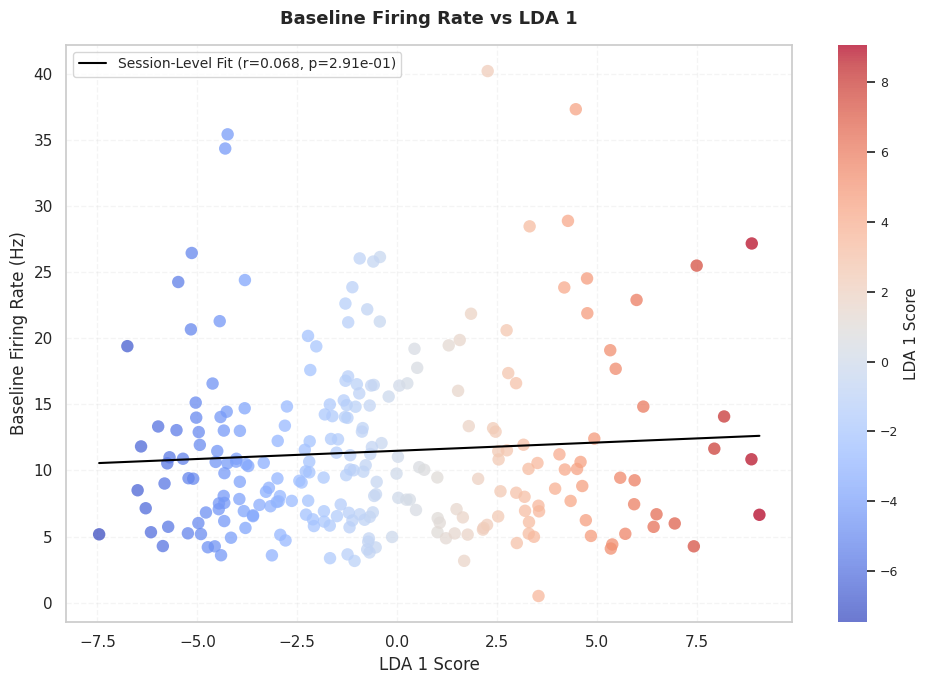

In [18]:
# Plot correlation with ff_quench aesthetics
fig, ax = plt.subplots(figsize=(10, 7))

x = valid_data['lda_1'].values
y = valid_data['baseline_fr_mean'].values

# Scatter with color gradient based on LDA 1
sc = ax.scatter(
    x, y, 
    c=x, 
    cmap='coolwarm', 
    alpha=0.75, 
    s=80,
    edgecolors='none'
)

# Linear regression line
z = np.polyfit(x, y, 1)
p_fit = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(
    x_line, 
    p_fit(x_line), 
    color='black', 
    linewidth=1.5,
    label=f'Session-Level Fit (r={r_pearson:.3f}, p={p_pearson:.2e})'
)

# Colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('LDA 1 Score', fontsize=11)
cbar.ax.tick_params(labelsize=9)
cbar.outline.set_visible(False)

# Labels and styling
ax.set_xlabel('LDA 1 Score', fontsize=12)
ax.set_ylabel('Baseline Firing Rate (Hz)', fontsize=12)
ax.set_title('Baseline Firing Rate vs LDA 1', fontsize=13, fontweight='bold', pad=15)
ax.grid(True, alpha=0.2, linestyle='--')
ax.legend(fontsize=10, loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

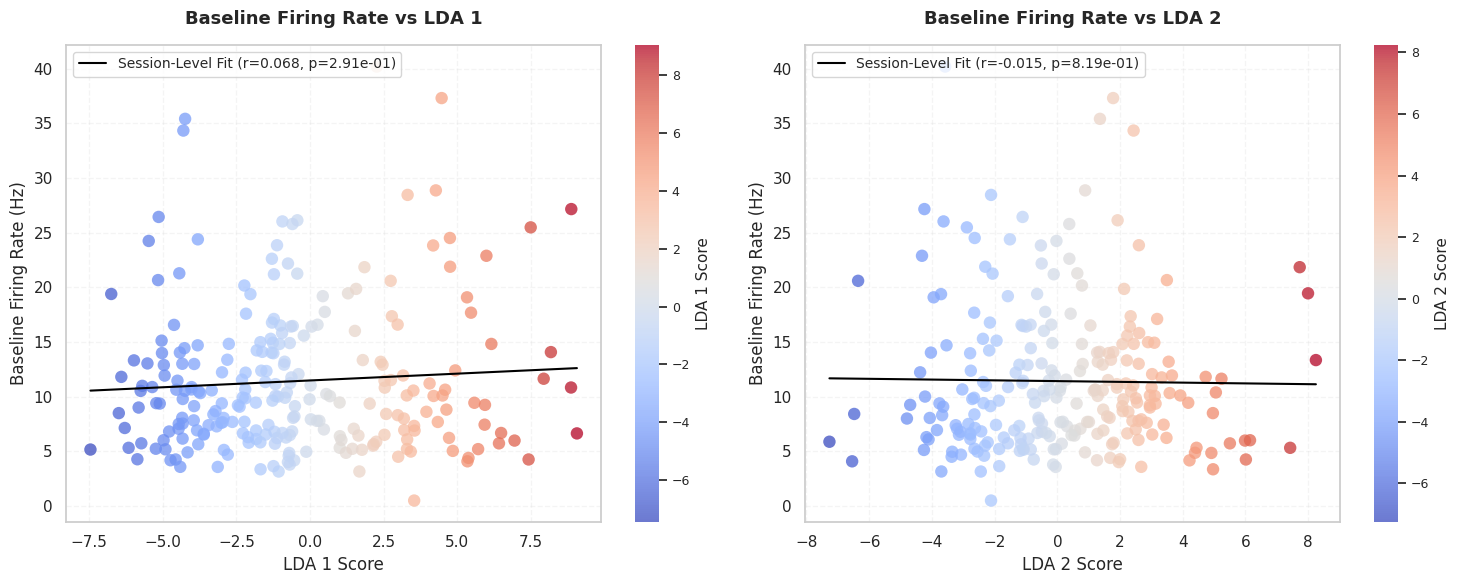

In [17]:
# Additional visualization: baseline FR vs LDA 1 and LDA 2 with ff_quench aesthetics
valid_data_lda2 = baseline_with_lda[['baseline_fr_mean', 'lda_2']].dropna()
r_lda2, p_lda2 = pearsonr(valid_data_lda2['baseline_fr_mean'], valid_data_lda2['lda_2'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# LDA 1
x1 = valid_data['lda_1'].values
y1 = valid_data['baseline_fr_mean'].values

sc1 = ax1.scatter(
    x1, y1, 
    c=x1, 
    cmap='coolwarm', 
    alpha=0.75, 
    s=80,
    edgecolors='none'
)

z1 = np.polyfit(x1, y1, 1)
p_fit1 = np.poly1d(z1)
x_line1 = np.linspace(x1.min(), x1.max(), 100)
ax1.plot(x_line1, p_fit1(x_line1), color='black', linewidth=1.5,
         label=f'Session-Level Fit (r={r_pearson:.3f}, p={p_pearson:.2e})')

cbar1 = fig.colorbar(sc1, ax=ax1)
cbar1.set_label('LDA 1 Score', fontsize=11)
cbar1.ax.tick_params(labelsize=9)
cbar1.outline.set_visible(False)

ax1.set_xlabel('LDA 1 Score', fontsize=12)
ax1.set_ylabel('Baseline Firing Rate (Hz)', fontsize=12)
ax1.set_title('Baseline Firing Rate vs LDA 1', fontsize=13, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.2, linestyle='--')
ax1.legend(fontsize=10, loc='upper left', frameon=True)

# LDA 2
x2 = valid_data_lda2['lda_2'].values
y2 = valid_data_lda2['baseline_fr_mean'].values

sc2 = ax2.scatter(
    x2, y2, 
    c=x2, 
    cmap='coolwarm', 
    alpha=0.75, 
    s=80,
    edgecolors='none'
)

z2 = np.polyfit(x2, y2, 1)
p_fit2 = np.poly1d(z2)
x_line2 = np.linspace(x2.min(), x2.max(), 100)
ax2.plot(x_line2, p_fit2(x_line2), color='black', linewidth=1.5,
         label=f'Session-Level Fit (r={r_lda2:.3f}, p={p_lda2:.2e})')

cbar2 = fig.colorbar(sc2, ax=ax2)
cbar2.set_label('LDA 2 Score', fontsize=11)
cbar2.ax.tick_params(labelsize=9)
cbar2.outline.set_visible(False)

ax2.set_xlabel('LDA 2 Score', fontsize=12)
ax2.set_ylabel('Baseline Firing Rate (Hz)', fontsize=12)
ax2.set_title('Baseline Firing Rate vs LDA 2', fontsize=13, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.2, linestyle='--')
ax2.legend(fontsize=10, loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

<Axes: xlabel='binned1', ylabel='baseline_fr_mean'>

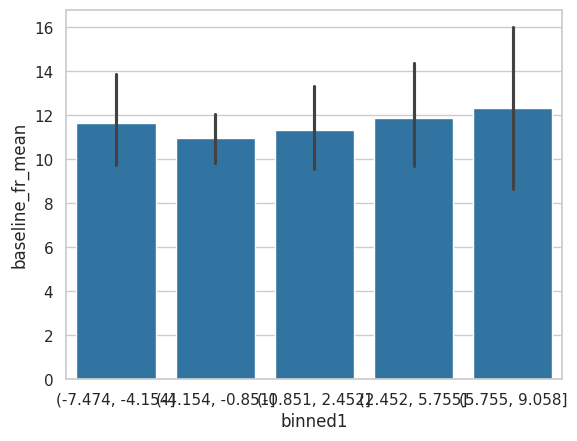

In [22]:
sns.barplot(x='binned1', y='baseline_fr_mean', data=baseline_with_lda)

## Summary Statistics

In [10]:
# Summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print(f"\nBaseline Firing Rate (aggregated at session level):")
print(baseline_with_lda[['baseline_fr_mean', 'baseline_fr_std', 'n_neurons']].describe())

print(f"\nLDA 1:")
print(baseline_with_lda['lda_1'].describe())

print(f"\nLDA 2:")
print(baseline_with_lda['lda_2'].describe())


SUMMARY STATISTICS

Baseline Firing Rate (aggregated at session level):
       baseline_fr_mean  baseline_fr_std   n_neurons
count        244.000000       244.000000  244.000000
mean          11.423839        15.148257  267.926230
std            6.647841         8.682952  182.676542
min            0.501253         1.080443    6.000000
25%            6.633946         8.934497  136.750000
50%            9.913582        13.217082  233.500000
75%           14.136432        19.931843  351.000000
max           40.204678        53.949711  831.000000

LDA 1:
count    244.000000
mean      -0.509161
std        3.621007
min       -7.456990
25%       -3.366240
50%       -1.027339
75%        2.180094
max        9.058085
Name: lda_1, dtype: float64

LDA 2:
count    244.000000
mean       0.108251
std        2.800235
min       -7.266710
25%       -2.118780
50%       -0.048484
75%        2.111232
max        8.245756
Name: lda_2, dtype: float64
